In [1]:
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

--2026-05-16 07:08:51--  https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-05-16 07:08:51 (13.0 MB/s) - ‘names.txt’ saved [228145/228145]



In [2]:
with open('names.txt', 'r') as f:
  names = f.read().splitlines()

In [3]:
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(names)

32033

In [5]:
min([len(name) for name in names])

2

In [6]:
max([len(name) for name in names])

15

In [18]:
b = {}

for name in names:
  chars = ['.'] + list(name) + ['.']
  for char1, char2 in zip(chars, chars[1:]):
    # print(char1, char2)
    bigram = (char1, char2)
    b[bigram] = b.get(bigram, 0) + 1

In [19]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

In [20]:
characters = sorted(list(set("".join(names))))
characters

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [21]:
stoi = {char:idx+1 for idx, char in enumerate(characters)}
stoi['.'] = 0
itos = {value:key for key, value in stoi.items()}

In [22]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [23]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [24]:
import torch

In [25]:
shape = len(stoi)

In [26]:
N = torch.zeros(shape, shape, dtype=torch.int32)

In [27]:
for name in names:
  characters = ['.'] + list(name) + ['.']
  for char1, char2 in zip(characters, characters[1:]):
    ix1 = stoi[char1]
    ix2 = stoi[char2]

    N[ix1, ix2] += 1

In [28]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

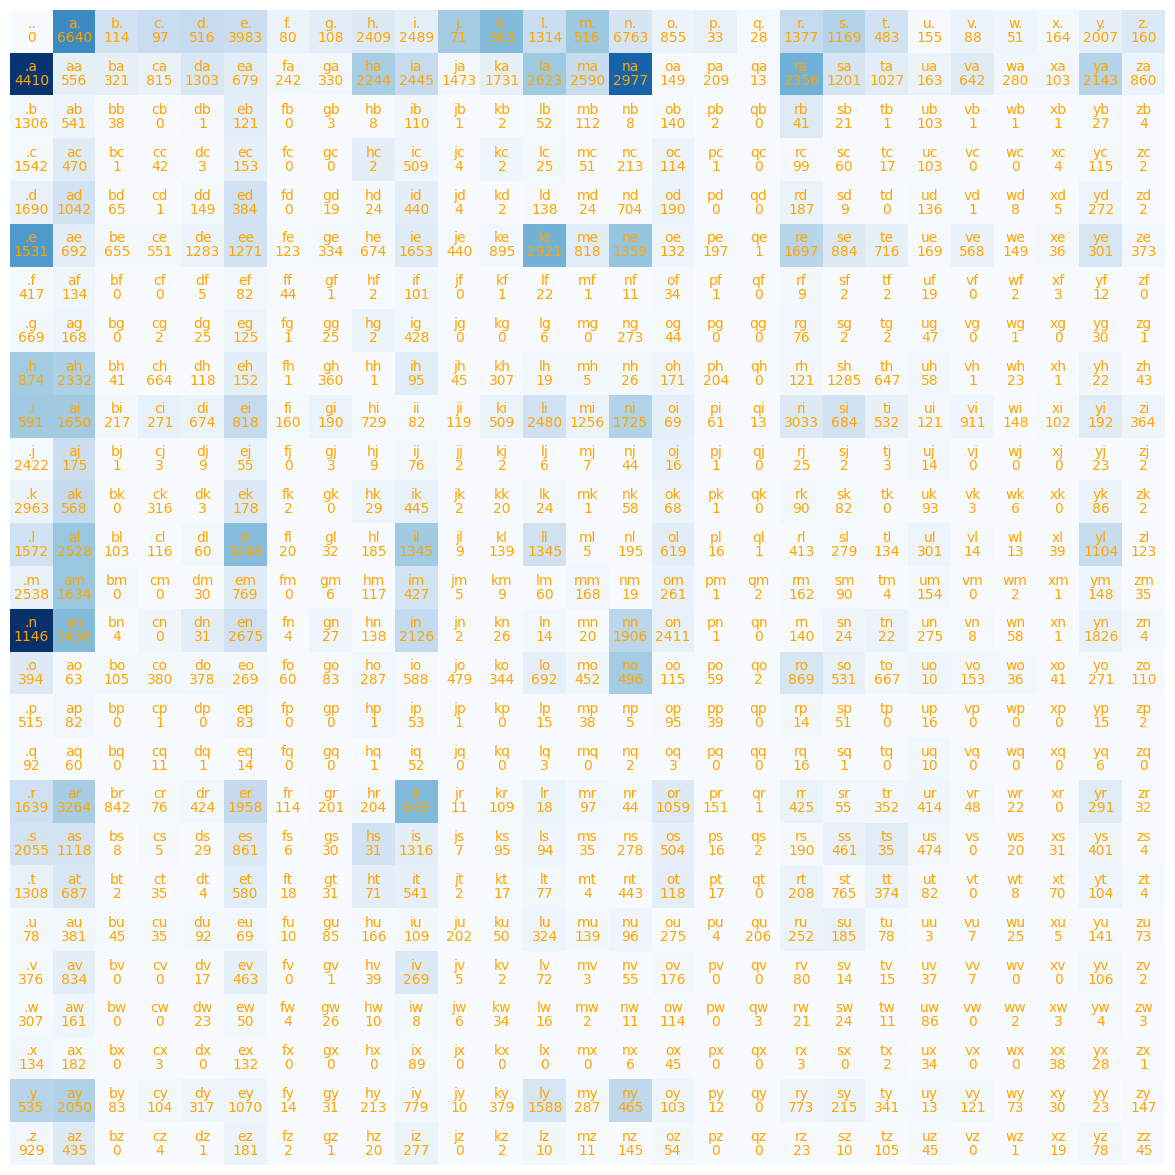

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.imshow(N, cmap='Blues')
for i in range(len(stoi)):
  for j in range(len(itos)):
    chrs = itos[i] + itos[j]
    plt.text(i, j, chrs, va='bottom', ha='center', color='orange')
    plt.text(i, j, N[i, j].item(), va='top', ha='center', color='orange')
plt.axis('off')

In [33]:
p = N[0]
# p = p / p.sum()
# p

In [34]:
p.sum()

tensor(32033)

In [43]:
g = torch.Generator().manual_seed(42)
# ix =

In [44]:
N.shape

torch.Size([27, 27])

In [46]:
N.sum(dim=1, keepdim=True).shape

torch.Size([27, 1])

In [47]:
P = N / N.sum(dim=1, keepdim=True)

In [48]:
P = (N+1).float()
P = P / P.sum(dim=1, keepdim=True)
P

tensor([[0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370,
         0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370,
         0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370],
        [0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370,
         0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370,
         0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370],
        [0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370,
         0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370,
         0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370],
        [0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370,
         0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370,
         0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370, 0.0370],
        [0.0370, 0.0370,

In [53]:
g = torch.Generator().manual_seed(42)
ix = 0

for _ in range(10):
  out = []
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])

    if ix == 0:
      break

  print(''.join(out))

xjugueovtps.
fabiquedxfmubnwmsflaypggzofmwhwlxoln.
epjccuodsgjdmzu.
xnxcmjjobdrggbdllk.
mnqhqyjfbhcvghigeaczalcvjwiajwtphjpdmqsotcc.
welqxosvgkocobr.
uklnncvrigmydysoumf.
pjjiewx.
lhmjuhm.
fsckbirdovhgn.
